# Least Squares for Multiclass Credit Risk Classification (Grades A–G)

## What are we solving?

We want to predict the **credit risk grade** of a loan applicant:

- **Target:** $\text{grade} \in \{A, B, C, D, E, F, G\}$ (7 classes)  
- Encoding: $\text{grade\_idx} \in \{0, \dots, 6\}$ with $A \to 0, \dots, G \to 6$
- **Input:** a mix of numeric and categorical features (one-hot encoded for categorical features)

---

## Why Least Squares for Classification?

Least Squares (LS) is normally used for regression, but we can adapt it for classification:

- Train the model to output a **score per class**  
- Predict the class with the **highest score**

Two common multiclass adaptations:

1. **One-vs-Rest (OvR):** train 7 separate LS classifiers (one class vs the rest)  
2. **Multivariate LS (one-hot targets):** solve a single matrix regression problem  

Here, we’ll follow the second, **“one model, many outputs”** approach.

---

## Model Setup

1. Build a **design matrix** $X$ (after preprocessing, plus bias column)  
2. Build a **one-hot label matrix** $Y$ (shape $N \times 7$)  
3. Fit weights $W$ so that:

$$
X W \approx Y
$$

4. Predict class by taking the **argmax** across the output scores:

$$
\hat{y} = \arg\max_k (X W)_k
$$

---

## What we will do in this notebook

- Load train/dev/test CSV files from Google Drive  
- Preprocess the data:
  - One-hot encode categorical features  
  - Standardize numeric features (using **train stats only**)  
  - Align columns across splits  
- Implement **Least Squares training + prediction**  
- Evaluate accuracy on train/dev/test sets and inspect the confusion matrix


In [ ]:
from google.colab import drive
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# Paths
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"
TEST_DIR  = DATA_ROOT / "Test"

train_csv = TRAIN_DIR / "train.csv"
dev_csv   = TRAIN_DIR / "dev.csv"
test_csv  = TEST_DIR  / "test.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

print("Train CSV exists:", train_csv.exists(), train_csv)
print("Dev CSV exists:", dev_csv.exists(), dev_csv)
print("Test CSV exists:", test_csv.exists(), test_csv)


DATA_ROOT exists: True
TRAIN_DIR exists: True
TEST_DIR exists: True
Train CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/train.csv
Dev CSV exists: True /content/drive/MyDrive/ML Project/Data/Train/dev.csv
Test CSV exists: True /content/drive/MyDrive/ML Project/Data/Test/test.csv


## Load train / dev / test data

We read the CSV files from Google Drive and do basic sanity checks:
- shape
- column names
- class distribution (grade_idx)


In [ ]:
train_df = pd.read_csv(train_csv)
dev_df   = pd.read_csv(dev_csv)
test_df  = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:", list(train_df.columns))

# Basic check: target column exists
assert "grade_idx" in train_df.columns, "Expected 'grade_idx' in train.csv"
assert "grade_idx" in dev_df.columns, "Expected 'grade_idx' in dev.csv"
assert "grade_idx" in test_df.columns, "Expected 'grade_idx' in test.csv"

# Class distribution
print("\nTrain grade_idx counts:\n", train_df["grade_idx"].value_counts().sort_index())
print("\nDev grade_idx counts:\n", dev_df["grade_idx"].value_counts().sort_index())
print("\nTest grade_idx counts:\n", test_df["grade_idx"].value_counts().sort_index())

train_df.head()


Train shape: (59619, 24)
Dev shape: (12775, 24)
Test shape: (12782, 24)

Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Train grade_idx counts:
 grade_idx
0    8517
1    8517
2    8517
3    8517
4    8517
5    8517
6    8517
Name: count, dtype: int64

Dev grade_idx counts:
 grade_idx
0    1825
1    1825
2    1825
3    1825
4    1825
5    1825
6    1825
Name: count, dtype: int64

Test grade_idx counts:
 grade_idx
0    1826
1    1826
2    1826
3    1826
4    1826
5    1826
6    1826
Name: count, dtype: int64


,grade,grade_idx,purpose,home_ownership,verification_status,addr_state,loan_amnt,term,emp_length,annual_inc,...,total_acc,pub_rec,revol_bal,revol_util,collections_12_mths_ex_med,acc_now_delinq,pub_rec_bankruptcies,tax_liens,credit_history_months,fico_avg
0,D,3,credit_card,RENT,Verified,CA,6000.0,36.0,10.0,65000.0,...,55.0,1.0,1363.0,3.6,0.0,0.0,1.0,0.0,218.020534,677.0
1,G,6,small_business,MORTGAGE,Source Verified,OH,14600.0,36.0,3.0,60000.0,...,11.0,0.0,6995.0,88.5,0.0,0.0,0.0,0.0,259.055441,667.0
2,G,6,debt_consolidation,MORTGAGE,Source Verified,CA,35000.0,36.0,10.0,184000.0,...,22.0,1.0,37361.0,62.7,0.0,0.0,0.0,1.0,128.985626,682.0
3,E,4,debt_consolidation,RENT,Source Verified,IL,15000.0,60.0,2.0,30000.0,...,38.0,0.0,13211.0,63.5,0.0,0.0,0.0,0.0,132.008214,672.0
4,E,4,debt_consolidation,RENT,Verified,MD,15200.0,60.0,4.0,38000.0,...,10.0,0.0,5600.0,70.0,0.0,0.0,0.0,0.0,223.934292,697.0


## Define feature columns

We have:
- Categorical features: purpose, home_ownership, verification_status, addr_state
- Numeric features: everything else (except labels)



In [ ]:
LABEL_COLS = ["grade", "grade_idx"]

CATEGORICAL_COLS = [
    "purpose",
    "home_ownership",
    "verification_status",
    "addr_state"
]

NUMERIC_COLS = [
    "loan_amnt",
    "term",
    "emp_length",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "total_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "pub_rec_bankruptcies",
    "tax_liens",
    "credit_history_months",
    "fico_avg"
]

FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS

missing = [c for c in (LABEL_COLS + FEATURE_COLS) if c not in train_df.columns]
print("Missing expected columns:", missing)


Missing expected columns: []


Quick class distribution plot

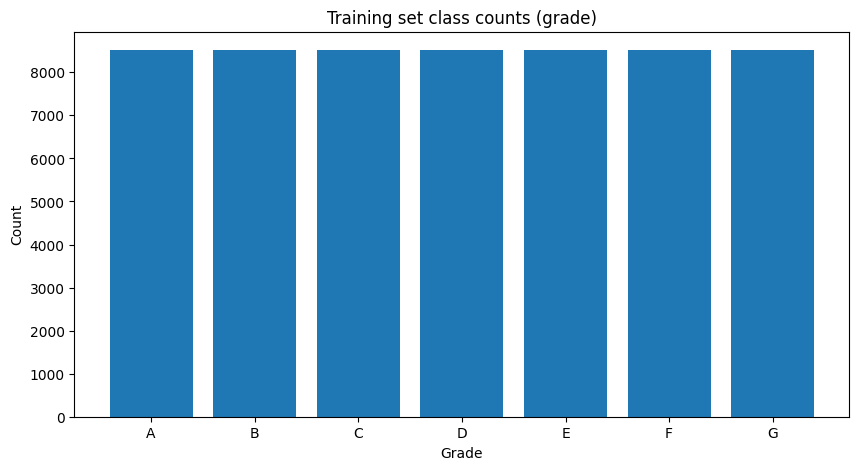

In [ ]:
counts = train_df["grade"].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title("Training set class counts (grade)")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()


Preprocessing helpers

We will:

One-hot encode categorical features

Standardize numeric features (train mean/std)

Align dev/test columns to train columns

Add a bias column

In [ ]:
def one_hot_encode(df, categorical_cols):
    return pd.get_dummies(df, columns=categorical_cols, drop_first=False)

def standardize_with_train_stats(train_df_enc, df_enc, numeric_cols):
    means = train_df_enc[numeric_cols].mean()
    stds  = train_df_enc[numeric_cols].std().replace(0, 1.0)
    out = df_enc.copy()
    out[numeric_cols] = (out[numeric_cols] - means) / stds
    return out, means, stds

def align_to_train_columns(train_encoded, other_encoded):
    return other_encoded.reindex(columns=train_encoded.columns, fill_value=0)

def add_bias_column(X_df):
    X = X_df.copy()
    X.insert(0, "bias", 1.0)
    return X


Build X/y matrices for train/dev/test

This produces X_train_np, y_train etc., ready for the Least Squares classifier

In [ ]:
# Labels
y_train = train_df["grade_idx"].to_numpy(dtype=int)
y_dev   = dev_df["grade_idx"].to_numpy(dtype=int)
y_test  = test_df["grade_idx"].to_numpy(dtype=int)

# Raw features
X_train_raw = train_df[FEATURE_COLS].copy()
X_dev_raw   = dev_df[FEATURE_COLS].copy()
X_test_raw  = test_df[FEATURE_COLS].copy()

# One-hot encode categorical
X_train_enc = one_hot_encode(X_train_raw, CATEGORICAL_COLS)
X_dev_enc   = one_hot_encode(X_dev_raw,   CATEGORICAL_COLS)
X_test_enc  = one_hot_encode(X_test_raw,  CATEGORICAL_COLS)

# Standardize numeric using train stats
X_train_std, train_means, train_stds = standardize_with_train_stats(X_train_enc, X_train_enc, NUMERIC_COLS)
X_dev_std,   _, _ = standardize_with_train_stats(X_train_enc, X_dev_enc,  NUMERIC_COLS)
X_test_std,  _, _ = standardize_with_train_stats(X_train_enc, X_test_enc, NUMERIC_COLS)

# Align dev/test columns to train columns
X_dev_std  = align_to_train_columns(X_train_std, X_dev_std)
X_test_std = align_to_train_columns(X_train_std, X_test_std)

# Add bias term
X_train = add_bias_column(X_train_std)
X_dev   = add_bias_column(X_dev_std)
X_test  = add_bias_column(X_test_std)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_dev:  ", X_dev.shape,   "y_dev:  ", y_dev.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

# Convert to NumPy
X_train_np = X_train.to_numpy(dtype=np.float64)
X_dev_np   = X_dev.to_numpy(dtype=np.float64)
X_test_np  = X_test.to_numpy(dtype=np.float64)


X_train: (59619, 92) y_train: (59619,)
X_dev:   (12775, 92) y_dev:   (12775,)
X_test:  (12782, 92) y_test:  (12782,)


Least Squares multiclass (implementation)

We implement:

one-hot encoding of labels

closed-form solution

prediction by argmax(XW, axis=1)

We include a small ridge term
𝜆 for numerical stability.

In [ ]:
def to_one_hot(y, num_classes):
    Y = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

def fit_least_squares_multiclass(X, y, num_classes=7, lam=1e-6):
    """
    X: (N, D) design matrix (including bias column if you want it)
    y: (N,) integer labels in {0,...,K-1}
    Returns:
      W: (D, K) weight matrix
    """
    N, D = X.shape
    Y = to_one_hot(y, num_classes)  # (N, K)

    # Ridge-regularized normal equation:
    # W = (X^T X + lam I)^(-1) X^T Y
    XtX = X.T @ X                       # (D, D)
    XtY = X.T @ Y                       # (D, K)

    I = np.eye(D, dtype=np.float64)
    # Often we don't regularize the bias term; optional:
    I[0, 0] = 0.0

    A = XtX + lam * I                   # (D, D)
    W = np.linalg.solve(A, XtY)         # (D, K)
    return W

def predict_least_squares_multiclass(X, W):
    """
    X: (N, D)
    W: (D, K)
    Returns:
      y_pred: (N,) predicted class index via argmax over class scores
    """
    scores = X @ W                      # (N, K)
    return np.argmax(scores, axis=1)


Evaluation helpers (accuracy + confusion matrix)

In [ ]:
def accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())

def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def plot_confusion_matrix(cm, class_names):
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names)
    plt.yticks(range(len(class_names)), class_names)
    plt.colorbar()
    plt.show()


Train LS model + report accuracies

We train on train split, then evaluate on train/dev/test.

In [ ]:
NUM_CLASSES = 7
CLASS_NAMES = ["A", "B", "C", "D", "E", "F", "G"]

lam = 1e-6

W = fit_least_squares_multiclass(X_train_np, y_train, num_classes=NUM_CLASSES, lam=lam)

y_pred_train = predict_least_squares_multiclass(X_train_np, W)
y_pred_dev   = predict_least_squares_multiclass(X_dev_np, W)
y_pred_test  = predict_least_squares_multiclass(X_test_np, W)

print(f"Lambda (ridge): {lam}")
print("Train accuracy:", accuracy(y_train, y_pred_train))
print("Dev accuracy:  ", accuracy(y_dev, y_pred_dev))
print("Test accuracy: ", accuracy(y_test, y_pred_test))


Lambda (ridge): 1e-06
Train accuracy: 0.33006256394773476
Dev accuracy:   0.326105675146771
Test accuracy:  0.32553590987325925


Confusion matrix on test set

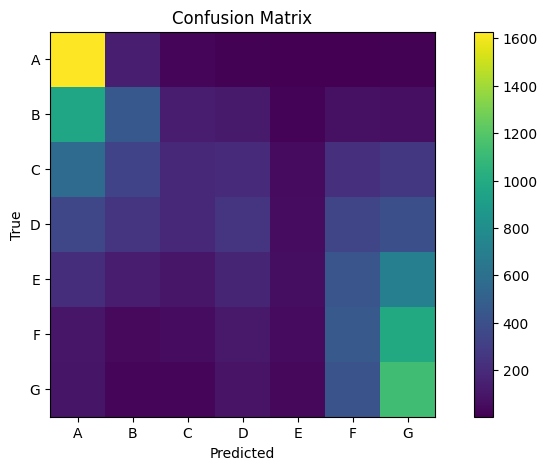

In [ ]:
cm_test = confusion_matrix(y_test, y_pred_test, num_classes=NUM_CLASSES)
plot_confusion_matrix(cm_test, CLASS_NAMES)


Accuracy

In [ ]:
lams = [0.0, 1e-8, 1e-6, 1e-4, 1e-2]
results = []

for lam in lams:
    W_l = fit_least_squares_multiclass(X_train_np, y_train, num_classes=NUM_CLASSES, lam=lam)
    pred_tr = predict_least_squares_multiclass(X_train_np, W_l)
    pred_d  = predict_least_squares_multiclass(X_dev_np,   W_l)
    pred_te = predict_least_squares_multiclass(X_test_np,  W_l)

    results.append({
        "lambda": lam,
        "train_acc": accuracy(y_train, pred_tr),
        "dev_acc": accuracy(y_dev, pred_d),
        "test_acc": accuracy(y_test, pred_te),
    })

pd.DataFrame(results)


,lambda,train_acc,dev_acc,test_acc
0,0.000000e+00,0.330063,0.326106,0.325536
1,1.000000e-08,0.330063,0.326106,0.325536
2,1.000000e-06,0.330063,0.326106,0.325536
3,1.000000e-04,0.330063,0.326106,0.325536
4,1.000000e-02,0.330063,0.326106,0.325536


Conclusions

Overall performance: Least Squares achieved about 33% accuracy on Train/Dev/Test (Train 0.330, Dev 0.326, Test 0.326), which is well above random guessing for 7 balanced classes (~14.3%). The very similar accuracies across splits suggest the model generalizes consistently and is not strongly overfitting.

Confusion matrix pattern: The model predicts the extreme grades much better than the middle ones. Class A is often correctly classified (strong diagonal at A), and classes near the high-risk end (especially G) also show many correct predictions. In contrast, the middle grades (B–F) are frequently confused with neighboring grades, and E is rarely predicted correctly, with many E examples being pushed toward F/G.

Interpretation: This behavior is expected because Least Squares is a linear model trained with squared error, which is not tailored to classification boundaries. It tends to produce “softer” score separations and struggles when classes are close/overlapping (as credit grades often are), while separating more easily the extremes (low-risk vs high-risk).